In [1]:
import os
if os.path.basename(os.getcwd()) == 'Demonstrations':
    os.chdir('..')

<div style="background-color: #bee7ff; color: white; padding: 30px; border-radius: 0px;">
<h1 style="margin: 0;  color: #1e1a66">Reduced Order Modeling on Stokes Equations</h3>
</div>

Imports:

In [2]:
from scipy.sparse.linalg import spsolve

from Utilities.Stokes_felib import *
from Utilities.Mesh_processing import *

---

In [3]:
p_coarse, e_coarse, t_coarse = Plot_Initial_Refined_meshes(data_path='Meshes/exchanger_device_altered_mesh_data.npz', num_of_refinements=2, 
                                                           plot=False,
                                                           figsize=(16,4))
p_fine, e_fine, t_fine = refine(p_coarse, e_coarse, t_coarse)

In [4]:
# def viscosity(x, y, subdomain):
#     return abs(-(x**2 + y**2)+10)+1

def viscosity(x, y, subdomain):
    return np.where((x >= -2) & (x <= -1) &
                    (y >= 1/3) & (y <= 1),
                    1,
                    100)

v_t = evalOnTrigs(p_fine, t_fine, viscosity)

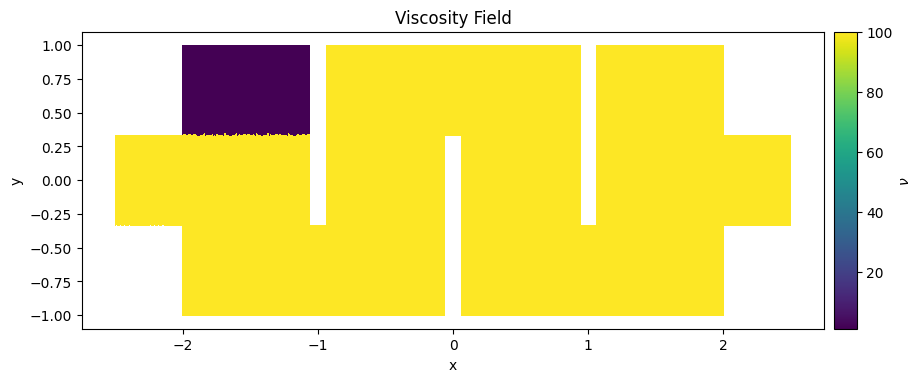

In [5]:
def plot_viscosity(p, t, nu_T,
                   figsize=(10,10),
                   savetype='png'):

    fig, ax = plt.subplots(figsize=figsize)

    triangulation = tri.Triangulation(
        p[:,0],
        p[:,1],
        t[:,:3]
    )

    cf = ax.tripcolor(
        triangulation,
        facecolors=nu_T,
        shading='flat'
    )

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="3%", pad=0.1)
    plt.colorbar(cf, cax=cax, label=r'$\nu$')

    ax.set_aspect('equal')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title('Viscosity Field')

    plt.savefig(f'Outputs/Viscosity.{savetype}',
                bbox_inches='tight')
    plt.show()

plot_viscosity(p_fine,
                t_fine, v_t)

In [11]:
def compute_U_P_solution(p_fine, t_fine, e_fine, p_coarse, t_coarse, v_t):

    Nv = p_fine.shape[0]
    Np = p_coarse.shape[0]
    eps = 1e-17

    xmin = p_fine[:, 0].min()
    xmax = p_fine[:, 0].max()

    inlet_idx  = np.where(np.abs(p_fine[:, 0] - xmin) < eps)[0]
    outlet_idx = np.where(np.abs(p_fine[:, 0] - xmax) < eps)[0]

    # Extract all physical boundary nodes from edge flags
    boundary_nodes = np.unique(e_fine[e_fine[:, 2] > 0, 0:2])

    # Exclude inlet and outlet from solid walls
    v_wall_idx = np.setdiff1d(boundary_nodes, np.concatenate([inlet_idx, outlet_idx]))

    lf_x = np.zeros(Nv)
    lf_y = np.zeros(Nv)
    lf_x[inlet_idx] = -1.0  
    
    A = calculate_velocity_A(p_fine, t_fine, kinematic_viscosity=v_t)
    Bx, By = calculate_pressure_B(p_fine, t_fine, p_coarse, t_coarse)
    F = calculate_F(A, Bx, By, (lf_x, lf_y))
    K = calculate_Saddle_point_K(A, Bx, By)
    K_matrix_structure(K, A.shape[0], Bx.shape[0], (7.5,7.5))
    print(f"K is of the shape {K.shape}")

    dirichlet_nodes = np.unique(np.concatenate([inlet_idx, v_wall_idx]))
    K = K.tolil()

    for i in dirichlet_nodes:
        # X-velocity tracks
        K[i, :] = 0.0
        K[i, i] = 1.0
        F[i] = 0.0  

        # Y-velocity tracks (shifted by Nv)
        iy = i + Nv
        K[iy, :] = 0.0
        K[iy, iy] = 1.0
        F[iy] = 0.0  

    is_outlet_p = (np.abs(p_coarse[:, 0] - xmax) < eps)
    p_ref_idx = np.where(is_outlet_p)[0]
    p_ref = p_ref_idx[0]
    p_row = 2 * Nv + p_ref

    K[p_row, :] = 0.0
    K[p_row, p_row] = 1.0
    F[p_row] = 0.0

    print("Solving lifted system...")
    sol = spsolve(K.tocsc(), F)

    if np.any(np.isnan(sol)):
        print("Warning: NaNs detected!")

    u0_x = sol[:Nv]
    u0_y = sol[Nv:2*Nv]
    pressure = sol[2*Nv:]

    ux = u0_x + lf_x
    uy = u0_y + lf_y

    div = Bx @ ux + By @ uy
    print("||div|| =", np.linalg.norm(div))
    print("max div =", np.max(np.abs(div)))

    return ux, uy, pressure


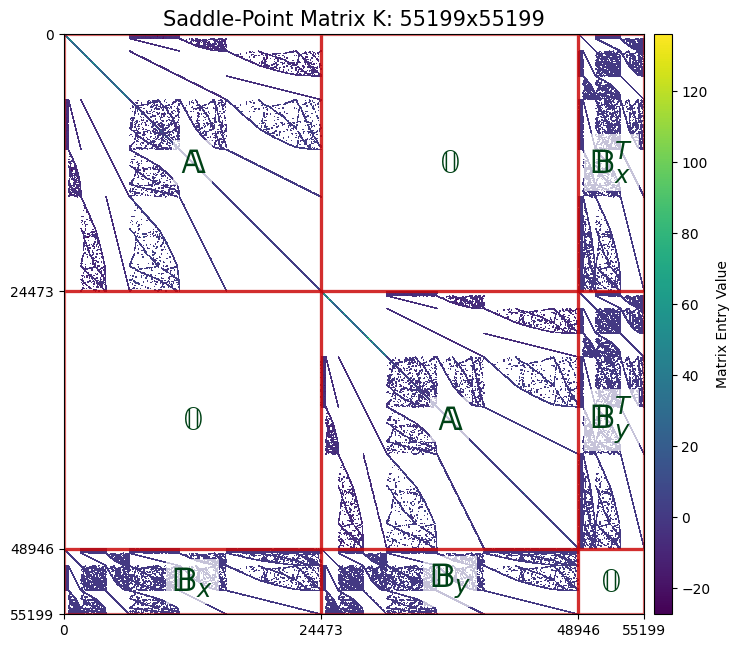

K is of the shape (55199, 55199)
Solving lifted system...
||div|| = 0.2627284786237427
max div = 0.07812499534339579
Simulation 'Exchanger_device_with_varying_viscosity' data saved.


In [12]:
ux, uy, p_sol = compute_U_P_solution(p_fine, t_fine, e_fine, p_coarse, t_coarse, 1)

save_simulation_data(p_fine, e_fine, t_fine, 
                    p_coarse, e_coarse, t_coarse, 
                    ux, uy, p_sol,
                    name='Exchanger_device_with_varying_viscosity')

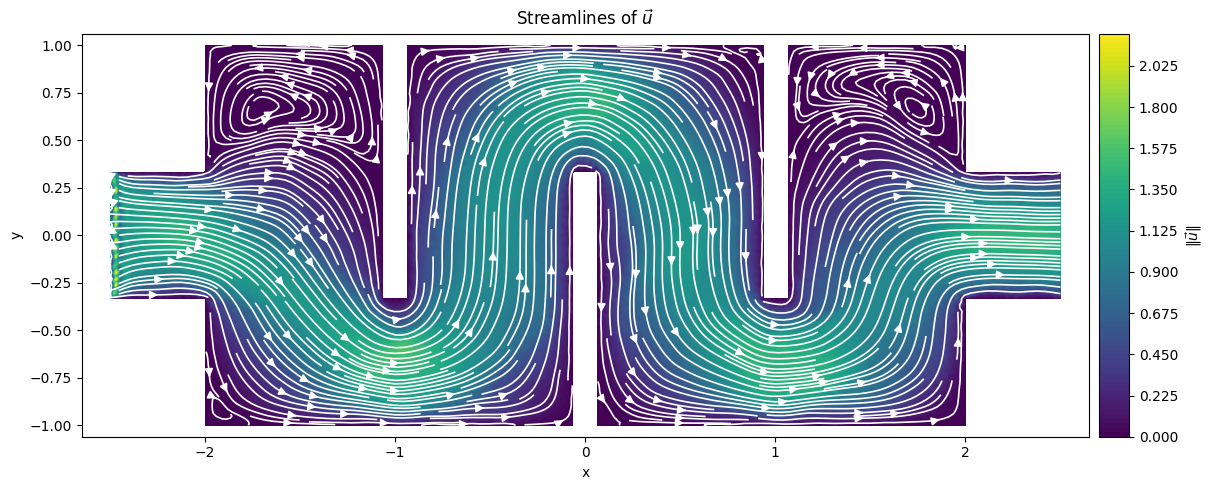

In [8]:
plot_streamlines(p_fine, t_fine, ux, uy,
                 grid_num=(500,500),
                 figsize=(15,5),
                 density=3.7)

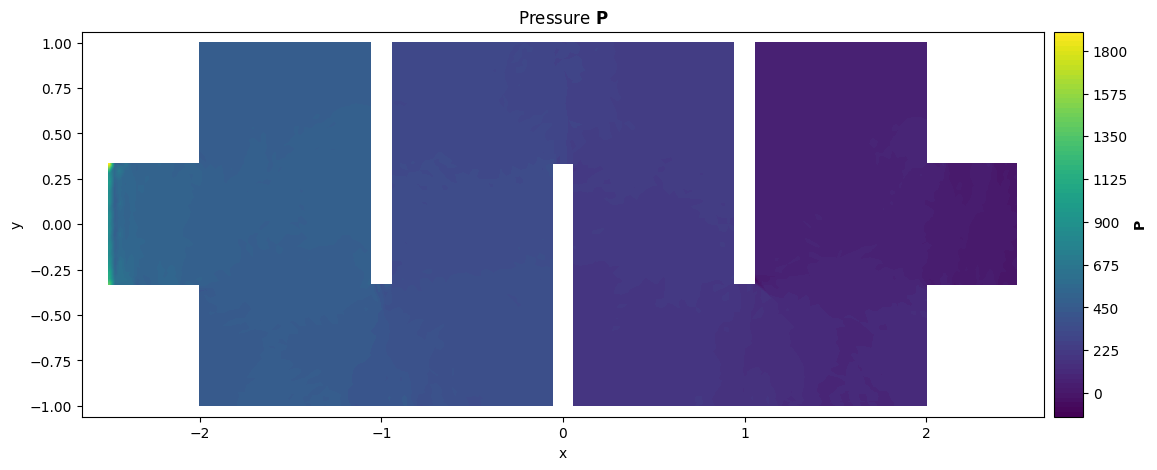

In [9]:
plot_pressure(p_coarse, t_coarse, p_sol,
              figsize=(15,5))